# Embedding Space Exploration

Visualizing how chunks are distributed in embedding space.

Goals:
- Understand what embeddings actually look like
- See how similar chunks cluster together
- Visualize the difference between related and unrelated chunks
- Use UMAP to reduce 384 dimensions → 2 dimensions for plotting

Key insight: if our embeddings are good, chunks about "attention mechanism"
should cluster together, away from chunks about "training details".

In [1]:
import subprocess
subprocess.run(["pip", "install", "umap-learn", "matplotlib", "pandas"], 
               capture_output=True)
print("Dependencies ready")

Dependencies ready


In [3]:
import sys
sys.path.append('..')

from src.data.loader import DocumentLoader
from src.data.chunker import get_chunker
from src.embeddings.dense import DenseEmbedder
import numpy as np

# Load paper
loader = DocumentLoader()
docs   = loader.load("../src/data/raw/attention_is_all_you_need.pdf")

# Use sliding window for consistent chunk sizes
chunker = get_chunker("sliding_window")
chunks  = chunker.chunk(docs)

print(f"Total chunks: {len(chunks)}")
print(f"Embedding all chunks...")

# Embed all chunks
embedder = DenseEmbedder()
texts    = [chunk.content for chunk in chunks]
vectors  = embedder.embed(texts, show_progress=True)

print(f"Vectors shape: {vectors.shape}")
print(f"Each chunk → {vectors.shape[1]}-dimensional vector")

2026-06-06 13:34:47 | INFO | src.data.loader | Loading PDF
2026-06-06 13:34:48 | INFO | src.data.loader | Loaded PDF
2026-06-06 13:34:48 | INFO | src.data.chunker | Sliding window chunking complete
Total chunks: 21
Embedding all chunks...


c:\Users\Snapp\anaconda3\envs\rag-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-06 13:34:55 | INFO | src.embeddings.dense | Loading dense embedding model


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]

Vectors shape: (21, 384)
Each chunk → 384-dimensional vector


## Dimensionality Reduction with UMAP

We have 384-dimensional vectors — impossible to visualize directly.

UMAP (Uniform Manifold Approximation and Projection) reduces them to 2D
while preserving the neighborhood structure.

Chunks that are close in 384D space stay close in 2D space.
This means: **clusters in the plot = semantically similar chunks**.

In [4]:
import umap

print("Running UMAP dimensionality reduction...")
print("(384 dimensions → 2 dimensions)")

reducer    = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
vectors_2d = reducer.fit_transform(vectors)

print(f"Done. Shape: {vectors_2d.shape}")
print(f"X range: [{vectors_2d[:,0].min():.2f}, {vectors_2d[:,0].max():.2f}]")
print(f"Y range: [{vectors_2d[:,1].min():.2f}, {vectors_2d[:,1].max():.2f}]")

Running UMAP dimensionality reduction...
(384 dimensions → 2 dimensions)


c:\Users\Snapp\anaconda3\envs\rag-eval\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done. Shape: (21, 2)
X range: [-4.77, -0.94]
Y range: [6.59, 11.08]


## Visualization 1: Chunks colored by page number

Each point is one chunk. Color = page number.
We expect chunks from nearby pages to cluster together
since papers have a natural flow of topics.

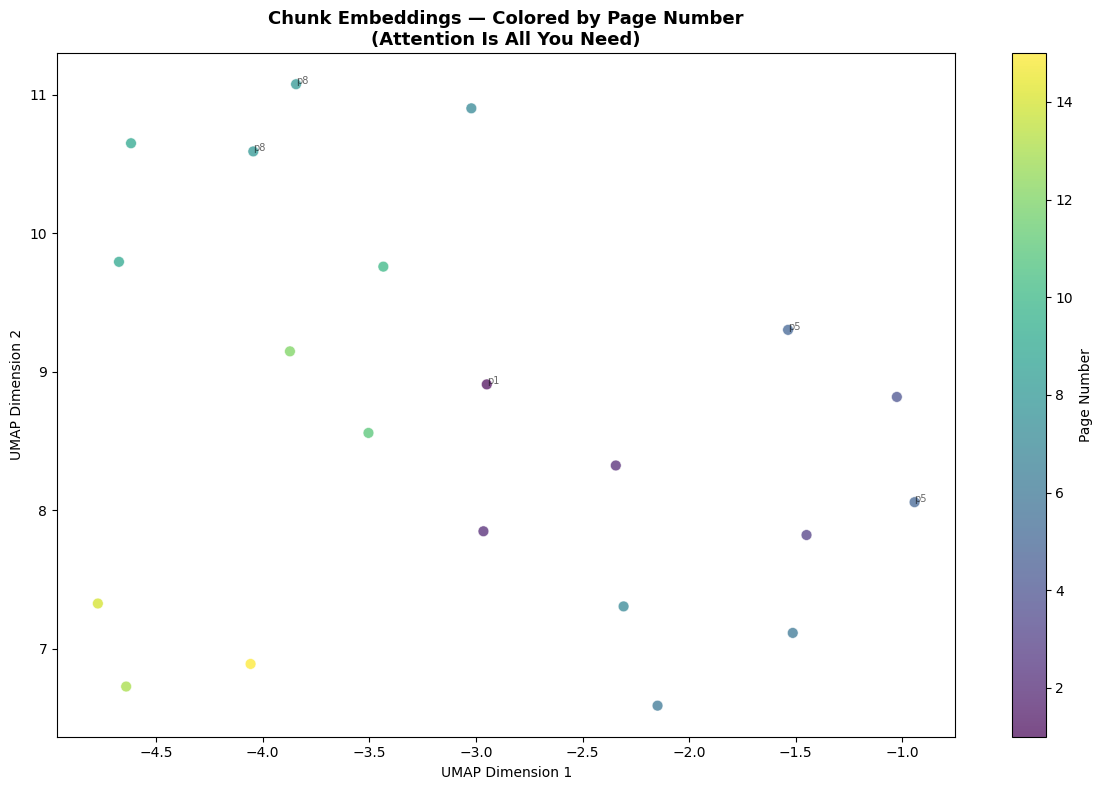

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

pages = [c.metadata.get("page", 0) for c in chunks]
max_page = max(pages)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    c=pages,
    cmap='viridis',
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
)

plt.colorbar(scatter, ax=ax, label='Page Number')
ax.set_title('Chunk Embeddings — Colored by Page Number\n(Attention Is All You Need)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')

# Annotate a few interesting chunks
for i, chunk in enumerate(chunks):
    if chunk.metadata.get("page") in [1, 5, 8]:
        ax.annotate(
            f"p{chunk.metadata.get('page')}",
            (vectors_2d[i, 0], vectors_2d[i, 1]),
            fontsize=7,
            alpha=0.6,
        )

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/embeddings_by_page.png", dpi=150)
plt.show()

## Visualization 2: Query vs Chunks

Now let's embed 5 queries and plot them alongside the chunks.
The queries should land near their most relevant chunks.

This visually shows WHY vector search works.

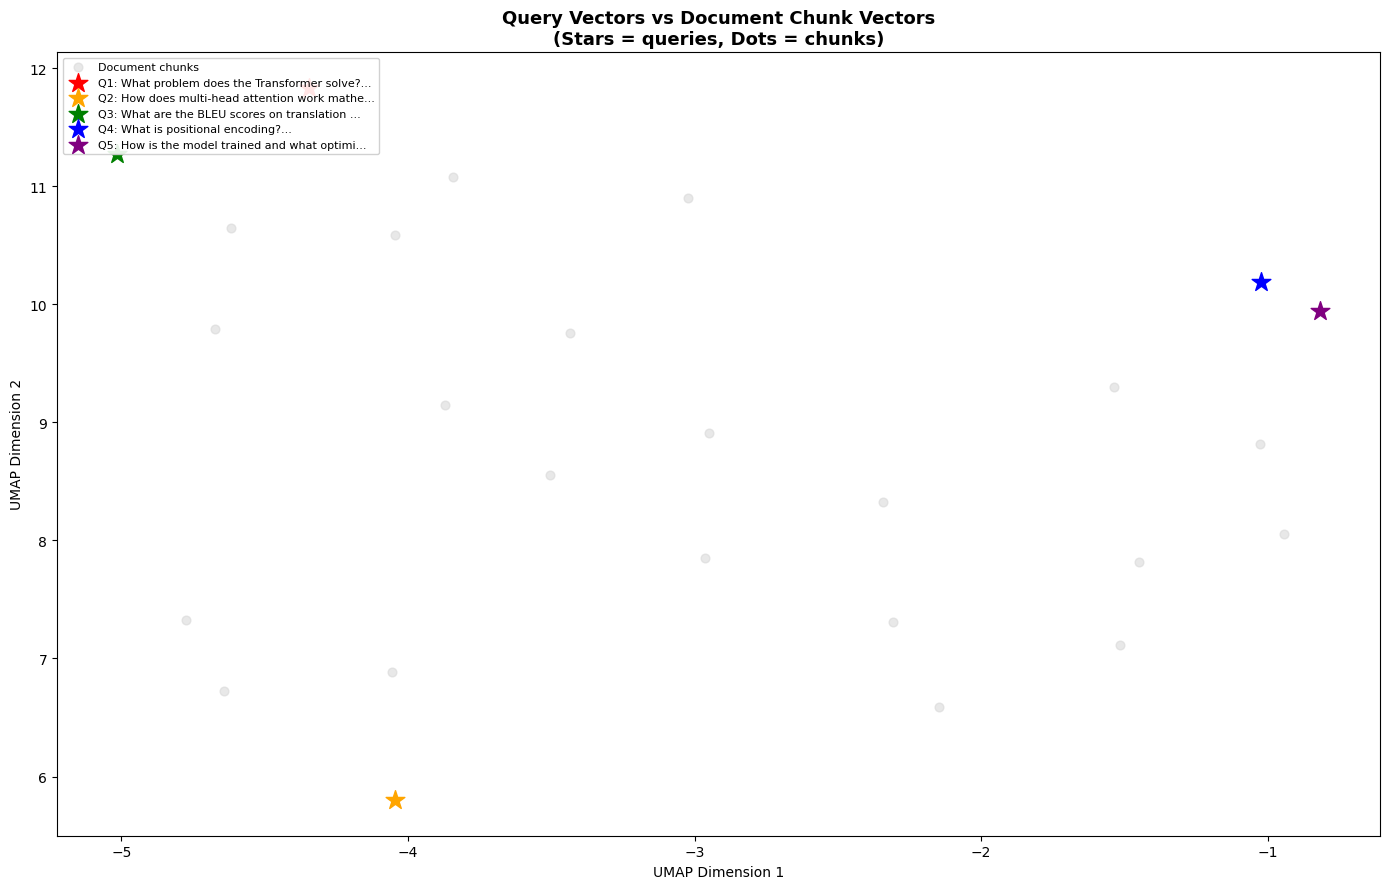

In [8]:
queries = [
    "What problem does the Transformer solve?",
    "How does multi-head attention work mathematically?",
    "What are the BLEU scores on translation tasks?",
    "What is positional encoding?",
    "How is the model trained and what optimizer is used?",
]

query_colors = ['red', 'orange', 'green', 'blue', 'purple']

# Embed queries
query_vectors    = embedder.embed(queries)
query_vectors_2d = reducer.transform(query_vectors)

fig, ax = plt.subplots(figsize=(14, 9))

# Plot chunks (background)
ax.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    c='lightgray',
    s=40,
    alpha=0.5,
    label='Document chunks',
)

# Plot queries (foreground)
for i, (query, color) in enumerate(zip(queries, query_colors)):
    ax.scatter(
        query_vectors_2d[i, 0],
        query_vectors_2d[i, 1],
        c=color,
        s=200,
        marker='*',
        zorder=5,
        label=f"Q{i+1}: {query[:40]}...",
    )

ax.set_title('Query Vectors vs Document Chunk Vectors\n(Stars = queries, Dots = chunks)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/queries_vs_chunks.png", dpi=150)
plt.show()

## Visualization 3: Similarity heatmap between queries

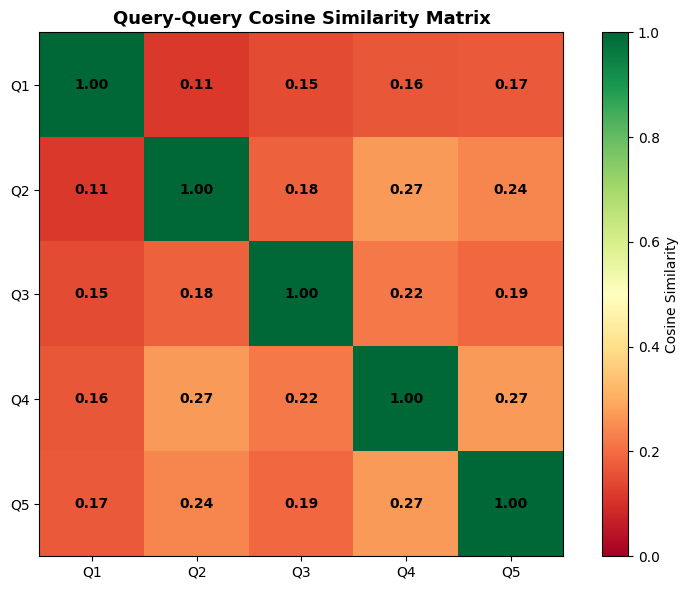


Most similar query pair:
  Q2: How does multi-head attention work mathematically?
  Q4: What is positional encoding?
  Similarity: 0.2722


In [9]:
import numpy as np

# Compute pairwise similarity between all queries
n = len(queries)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i][j] = float(np.dot(query_vectors[i], query_vectors[j]))

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

short_labels = [f"Q{i+1}" for i in range(n)]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels)
ax.set_yticklabels(short_labels)

# Add values in cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i][j]:.2f}",
                ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_title('Query-Query Cosine Similarity Matrix', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/query_similarity_matrix.png", dpi=150)
plt.show()

print("\nMost similar query pair:")
np.fill_diagonal(sim_matrix, 0)
i, j = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
print(f"  Q{i+1}: {queries[i]}")
print(f"  Q{j+1}: {queries[j]}")
print(f"  Similarity: {sim_matrix[i][j]:.4f}")

## Key Observations

1. **Page clustering**: Chunks from nearby pages tend to cluster — 
   the paper flows naturally from introduction → architecture → experiments

2. **Query placement**: Queries land near their relevant chunks — 
   this is why vector search works. Distance in embedding space = semantic similarity.

3. **Query similarity**: The heatmap shows which questions are semantically related.
   "Multi-head attention" and "positional encoding" are both about architecture,
   so they should be more similar to each other than to "BLEU scores."

4. **Outliers**: Some chunks appear isolated — these are likely figure captions,
   tables, or references that don't embed well with the main content.